In [3]:
import pandas as pd
import numpy as np
from pdb import set_trace as st
from copy import copy

# import packages
import pandas as pd # need to separately install openpyxl
import numpy as np

# Import plotting packages
import seaborn as sns
import matplotlib.pyplot as plt

# Import package for copying variables
from copy import copy

# Needed for creating a heatmap with seaborn
#   note this must be imported in the same command as seaborn to work with it
import scipy

# For printing a legend of column colors
import matplotlib.patches as mpatches

# For creating a dendrogram and extracting cluster assignments
from scipy.cluster.hierarchy import dendrogram, fcluster

import matplotlib.pyplot as plt

In [4]:
FilePath = '/Users/lanqihuang/Desktop/Melanocyte_RNAseq.xlsx'
Tab =  'MeSC'
DATA = pd.read_excel(io=FilePath, sheet_name=Tab, header=None)

In [5]:
DATA.index = DATA.iloc[:, 0]
DATA.columns = DATA.iloc[0,:]
DATA.head()

GeneID,GeneID,CT1,CT2,RTX1,RTX2
0,,,,,
GeneID,GeneID,CT1,CT2,RTX1,RTX2
Label,Label,CT1,CT2,RTX1,RTX2
Tyrp1,Tyrp1,3459.024679,3170.760504,8872.027922,9028.496103
Oca2,Oca2,14.75558,11.202846,37.98341,84.084888
Slc45a2,Slc45a2,269.351743,197.492052,493.215465,617.614551


In [6]:
DATA = DATA.drop('GeneID', axis = 0)
DATA = DATA.drop('GeneID', axis = 1)
DATA

GeneID,CT1,CT2,RTX1,RTX2
0,,,,
Label,CT1,CT2,RTX1,RTX2
Tyrp1,3459.024679,3170.760504,8872.027922,9028.496103
Oca2,14.75558,11.202846,37.98341,84.084888
Slc45a2,269.351743,197.492052,493.215465,617.614551
Pmel,7248.216936,4275.639562,14974.885789,13868.675977
Trpm1,105.649728,56.954305,171.362713,200.447265
Cd63,2690.14375,3031.035412,4933.830668,4946.177312
Myo5a,196.212914,229.110085,400.665608,351.264073
Kit,637.236435,676.847658,990.39327,1242.103818


In [7]:
DATA.index.name=None
DATA.columns.name = None
DATA

,CT1,CT2,RTX1,RTX2
Label,CT1,CT2,RTX1,RTX2
Tyrp1,3459.024679,3170.760504,8872.027922,9028.496103
Oca2,14.75558,11.202846,37.98341,84.084888
Slc45a2,269.351743,197.492052,493.215465,617.614551
Pmel,7248.216936,4275.639562,14974.885789,13868.675977
Trpm1,105.649728,56.954305,171.362713,200.447265
Cd63,2690.14375,3031.035412,4933.830668,4946.177312
Myo5a,196.212914,229.110085,400.665608,351.264073
Kit,637.236435,676.847658,990.39327,1242.103818
Mc1r,50.04359,20.279265,72.28715,106.292239


In [8]:
Sample_Labels = DATA.loc['Label',:]
Sample_Labels = DATA.loc['Label',:]
DATA = DATA.drop('Label')
DATA

DATA

,CT1,CT2,RTX1,RTX2
Tyrp1,3459.024679,3170.760504,8872.027922,9028.496103
Oca2,14.75558,11.202846,37.98341,84.084888
Slc45a2,269.351743,197.492052,493.215465,617.614551
Pmel,7248.216936,4275.639562,14974.885789,13868.675977
Trpm1,105.649728,56.954305,171.362713,200.447265
Cd63,2690.14375,3031.035412,4933.830668,4946.177312
Myo5a,196.212914,229.110085,400.665608,351.264073
Kit,637.236435,676.847658,990.39327,1242.103818
Mc1r,50.04359,20.279265,72.28715,106.292239
Tyr,323.094845,229.033698,510.141622,452.880481


In [9]:
from scipy.stats import zscore
DATA=DATA.astype(float)
DATA = DATA.apply(lambda x: zscore(x, nan_policy = 'omit'), axis = 1)
DATA=DATA.replace([np.inf, -np.inf], np.nan).fillna(0)
DATA

,CT1,CT2,RTX1,RTX2
Tyrp1,-0.948045,-1.050264,0.971412,1.026896
Oca2,-0.765658,-0.887907,0.033609,1.619956
Slc45a2,-0.740834,-1.166496,0.585225,1.322105
Pmel,-0.635765,-1.300358,1.091722,0.844402
Trpm1,-0.499048,-1.368389,0.674101,1.193336
Cd63,-1.156184,-0.830495,0.987442,0.999238
Myo5a,-1.163635,-0.773419,1.261520,0.675534
Kit,-1.011207,-0.850607,0.420638,1.441177
Mc1r,-0.387609,-1.334658,0.320142,1.402125
Tyr,-0.506972,-1.363210,1.195715,0.674467


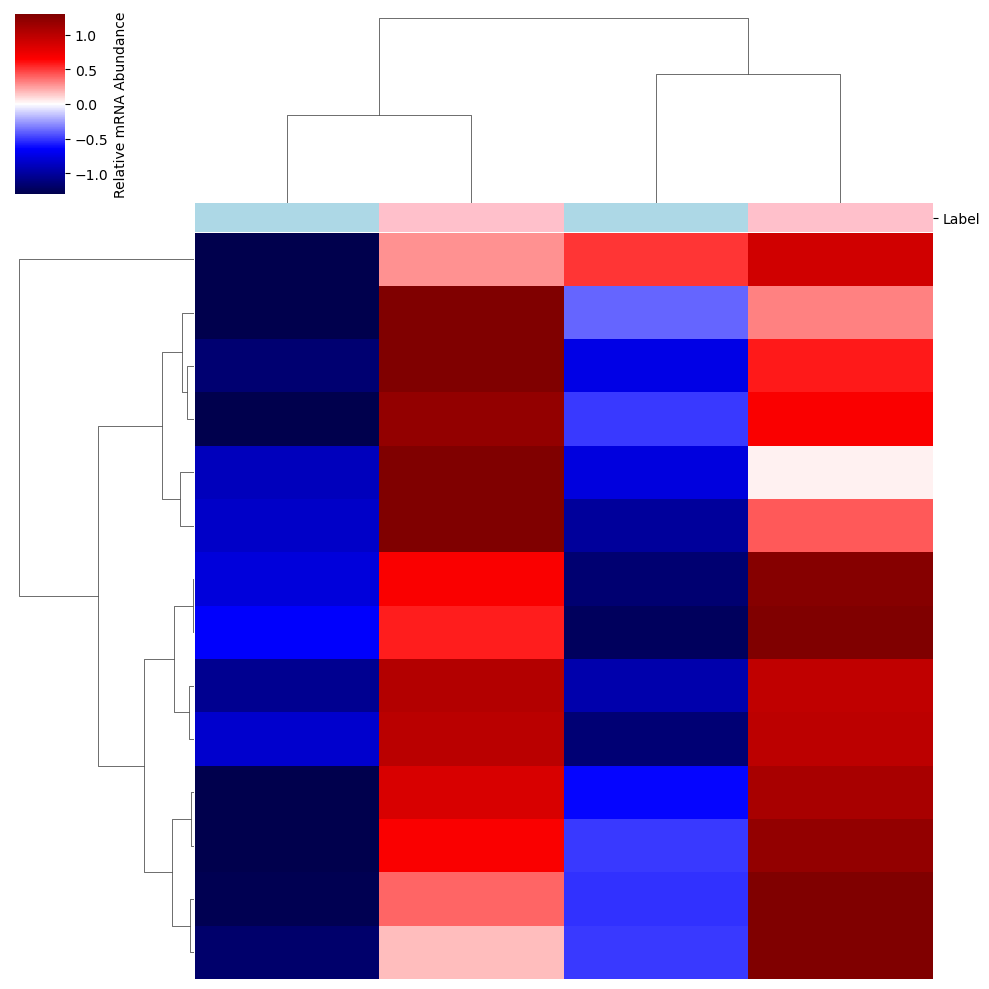

In [10]:
DATA = DATA.apply(pd.to_numeric, errors='coerce')
# Assuming you have already loaded your data into a DataFrame named DATA

color_mapping = {'CT1': '#ADD8E6', 'CT2': '#ADD8E6','RTX1': 'pink', 'RTX2': 'pink'}
col_colors = Sample_Labels.map(color_mapping)

# Calculate pairwise Pearson correlation coefficients
correlation_matrix = DATA.corr()

# Set the minimum and maximum color values
min_color = -1.3
max_color = 1.3

# Plot the clustermap with hierarchical clustering using Pearson correlation and average linkage
hm = sns.clustermap(data=DATA,
                    method='average',  # Change method to 'average' for average linkage
                    metric='correlation',  # Change metric to 'correlation' for Pearson correlation
                    yticklabels=False,
                    xticklabels=False,
                    vmin=min_color,
                    vmax=max_color,
                    cmap='seismic', 
                    col_colors=col_colors,
                    cbar_kws={'label': 'Relative mRNA Abundance'})

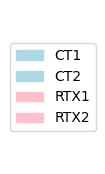

In [11]:
# Create legend
legend_patches = [mpatches.Patch(color=color, label=category) for category, color in color_mapping.items()]
legend_fig = plt.figure(figsize=(0.5, 2))
ax = legend_fig.add_subplot()
ax.legend(handles=legend_patches, loc='center')
ax.axis('off')  # Turn off the axis
plt.show()

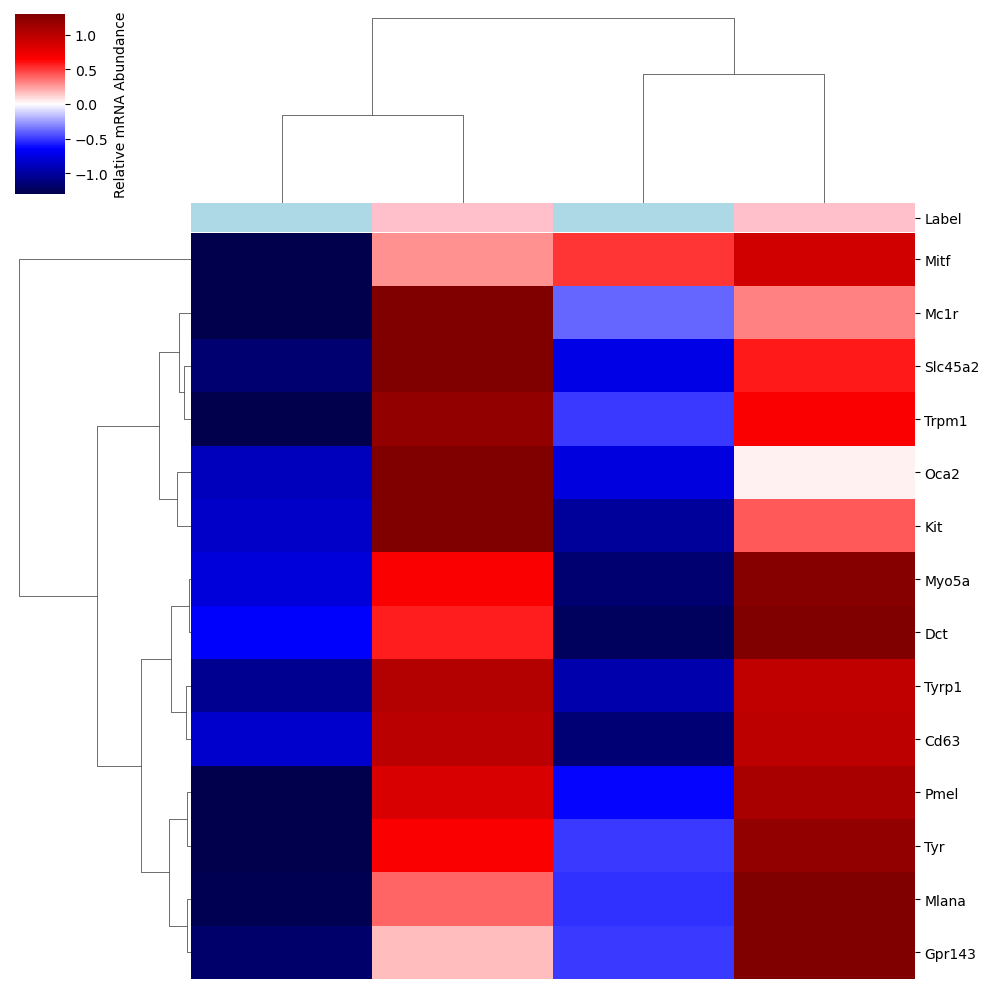

In [12]:
hm = sns.clustermap(data=DATA,
                    method='average',  # Change method to 'average' for average linkage
                    metric='correlation',  # Change metric to 'correlation' for Pearson correlation
                    yticklabels=True,  # Change to True to show gene names
                    xticklabels=False,
                    vmin=min_color,
                    vmax=max_color,
                    cmap='seismic', 
                    col_colors=col_colors,
                    cbar_kws={'label': 'Relative mRNA Abundance'})

<Axes: >

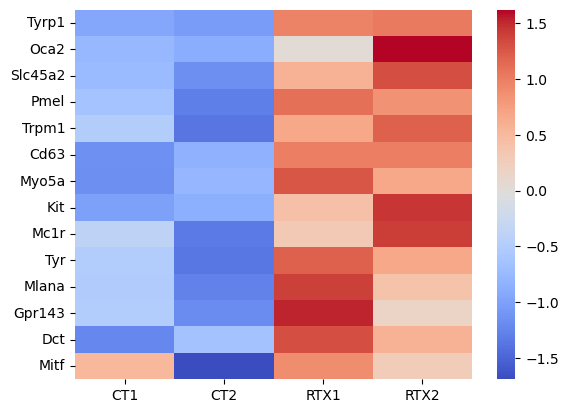

In [22]:
import seaborn as sns
import pandas as pd
from scipy.cluster import hierarchy
from scipy.spatial import distance


# Calculate the distances between each pair of samples
dist = distance.pdist(DATA.T.values, metric='euclidean')

# Perform hierarchical/agglomerative clustering
linkage = hierarchy.linkage(dist, method='average')

# Create a dendrogram (tree) based on the hierarchical clustering
dendro = hierarchy.dendrogram(linkage, labels=DATA.columns, no_plot=True)

# Reorder the data according to the clustering
df_clustered = DATA[dendro['ivl']]

# Plot the heatmap
sns.heatmap(df_clustered, cmap='coolwarm')